# Load tracked peaks from MMA code (Tim)

Index(['MAPI_1pct_ABA_S1_30_tube_5min 003294 Spectrums_110_time (s)',
       'MAPI_1pct_ABA_S1_30_tube_5min 003294 Spectrums_110_amplitude (au)',
       'MAPI_1pct_ABA_S1_30_tube_5min 003294 Spectrums_110_center ($\AA$)',
       'MAPI_1pct_ABA_S1_30_tube_5min 003294 Spectrums_110_sigma ($\AA$)',
       'MAPI_1pct_ABA_S1_30_tube_5min 003294 Spectrums_110_std error amplitude (au)',
       'MAPI_1pct_ABA_S1_30_tube_5min 003294 Spectrums_110_std error center ($\AA$)',
       'MAPI_1pct_ABA_S1_30_tube_5min 003294 Spectrums_110_std error sigma ($\AA$)'],
      dtype='object')


/var/folders/__/58987p0j61jdtq4g47xqr55r0000gn/T/ipykernel_80261/4006112154.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Crystallite Radius (nm)'] = 2 * pi * k_shape / (df_filtered[fwhm_column]) / 10  / (4 * pi / 3)**(1/3)# nm. Using the definition of the scherrer size as the cube root of the volume of a sphere with the same radius as the crystallite size.


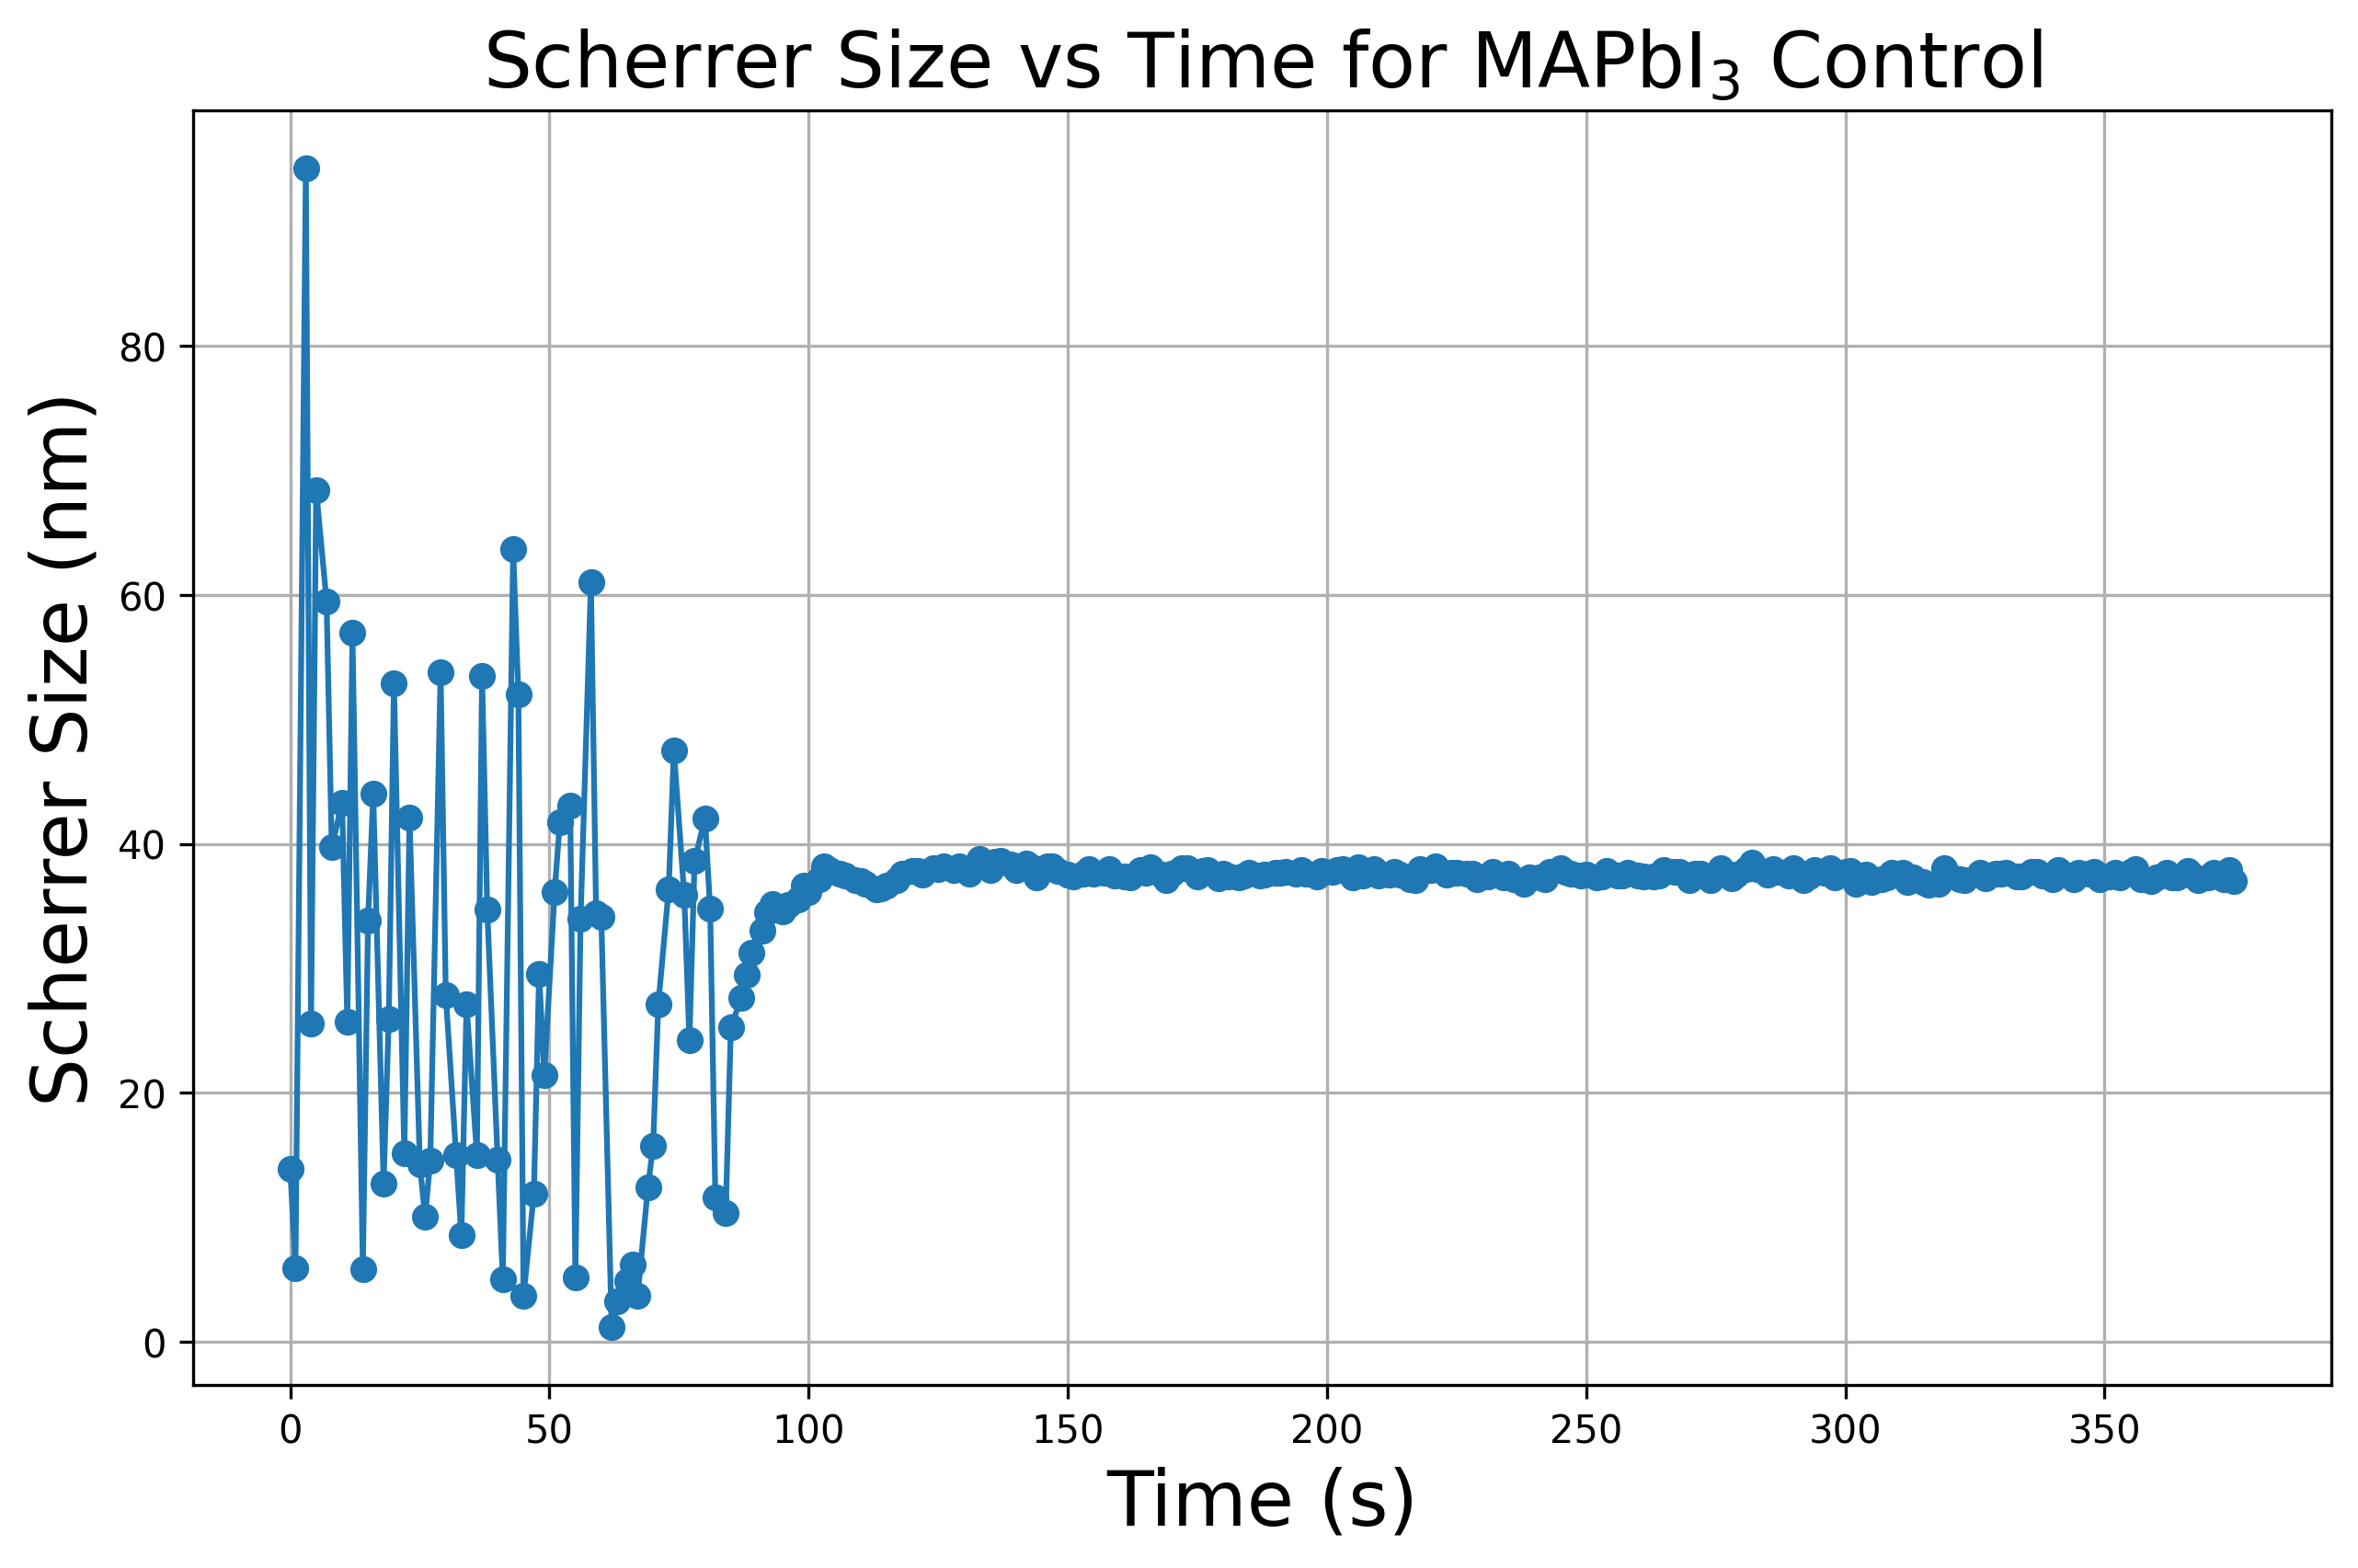

In [ ]:
import pandas as pd
import numpy as np
from scipy.constants import pi, h, c, electron_volt
from matplotlib import pyplot as plt

sample_name = r'MAPbI$_3$ ' + "Control"#w/ 1 mol% 4-ABA"
experiment_end_time = 375 #end of experiment in seconds

# Assuming K (shape factor) = 0.9
k_shape = 0.9

# Load the CSV file into a pandas DataFrame
df = pd.read_csv("/Users/pjlohr/Documents/GitHub/Patrick_Lohr/size_estimation_stuff/xrd_data/110_peak_fit_results_MAPI_1pct_ABA_S1_30_tube_5min 003294 Spectrums.csv")
print(df.columns)

time_column = df.columns[0]
amplitude_column = df.columns[1]
peak_position_column = df.columns[2]
sigma_column = df.columns[3]

# Drop rows where the specific column has NaN values
df_clean = df.dropna(subset=peak_position_column)

# Compute FWHM from sigma values
fwhm_column = 'FWHM (1/Å)' 
df_clean[fwhm_column] = 2 * np.sqrt(2 * np.log(2)) * df_clean[sigma_column] # Convert sigma to FWHM in 1/Å. gaussian and psuedo-Voigt fits share the same sigma value.

# Filter data up to the target time
df_filtered = df_clean[df_clean[time_column] <= experiment_end_time]

df_filtered['Crystallite Radius (nm)'] = 2 * pi * k_shape / (df_filtered[fwhm_column]) / 10  / (4 * pi / 3)**(1/3)# nm. Using the definition of the scherrer size as the cube root of the volume of a sphere with the same radius as the crystallite size.

fs = 20
# Plot Size (nm) vs Time (s)
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(df_filtered[time_column], df_filtered['Crystallite Radius (nm)'], marker='o')
plt.xlabel('Time (s)', fontsize=fs)
plt.ylabel('Scherrer Size (nm)', fontsize=fs)
plt.title(f'Scherrer Size vs Time for {sample_name}', fontsize=fs)
plt.grid(True)
plt.show()


# Plot All


/var/folders/__/58987p0j61jdtq4g47xqr55r0000gn/T/ipykernel_92440/2826468029.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Crystallite Radius (nm)'] = scherrer_size / (4 * np.pi / 3)**(1/3) # Scherrer size is taken to be the cube root of the volume of a sphere with the same radius as the crystallite size.
/var/folders/__/58987p0j61jdtq4g47xqr55r0000gn/T/ipykernel_92440/2826468029.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Crystallite Radius (nm)'] = scherrer_size / 

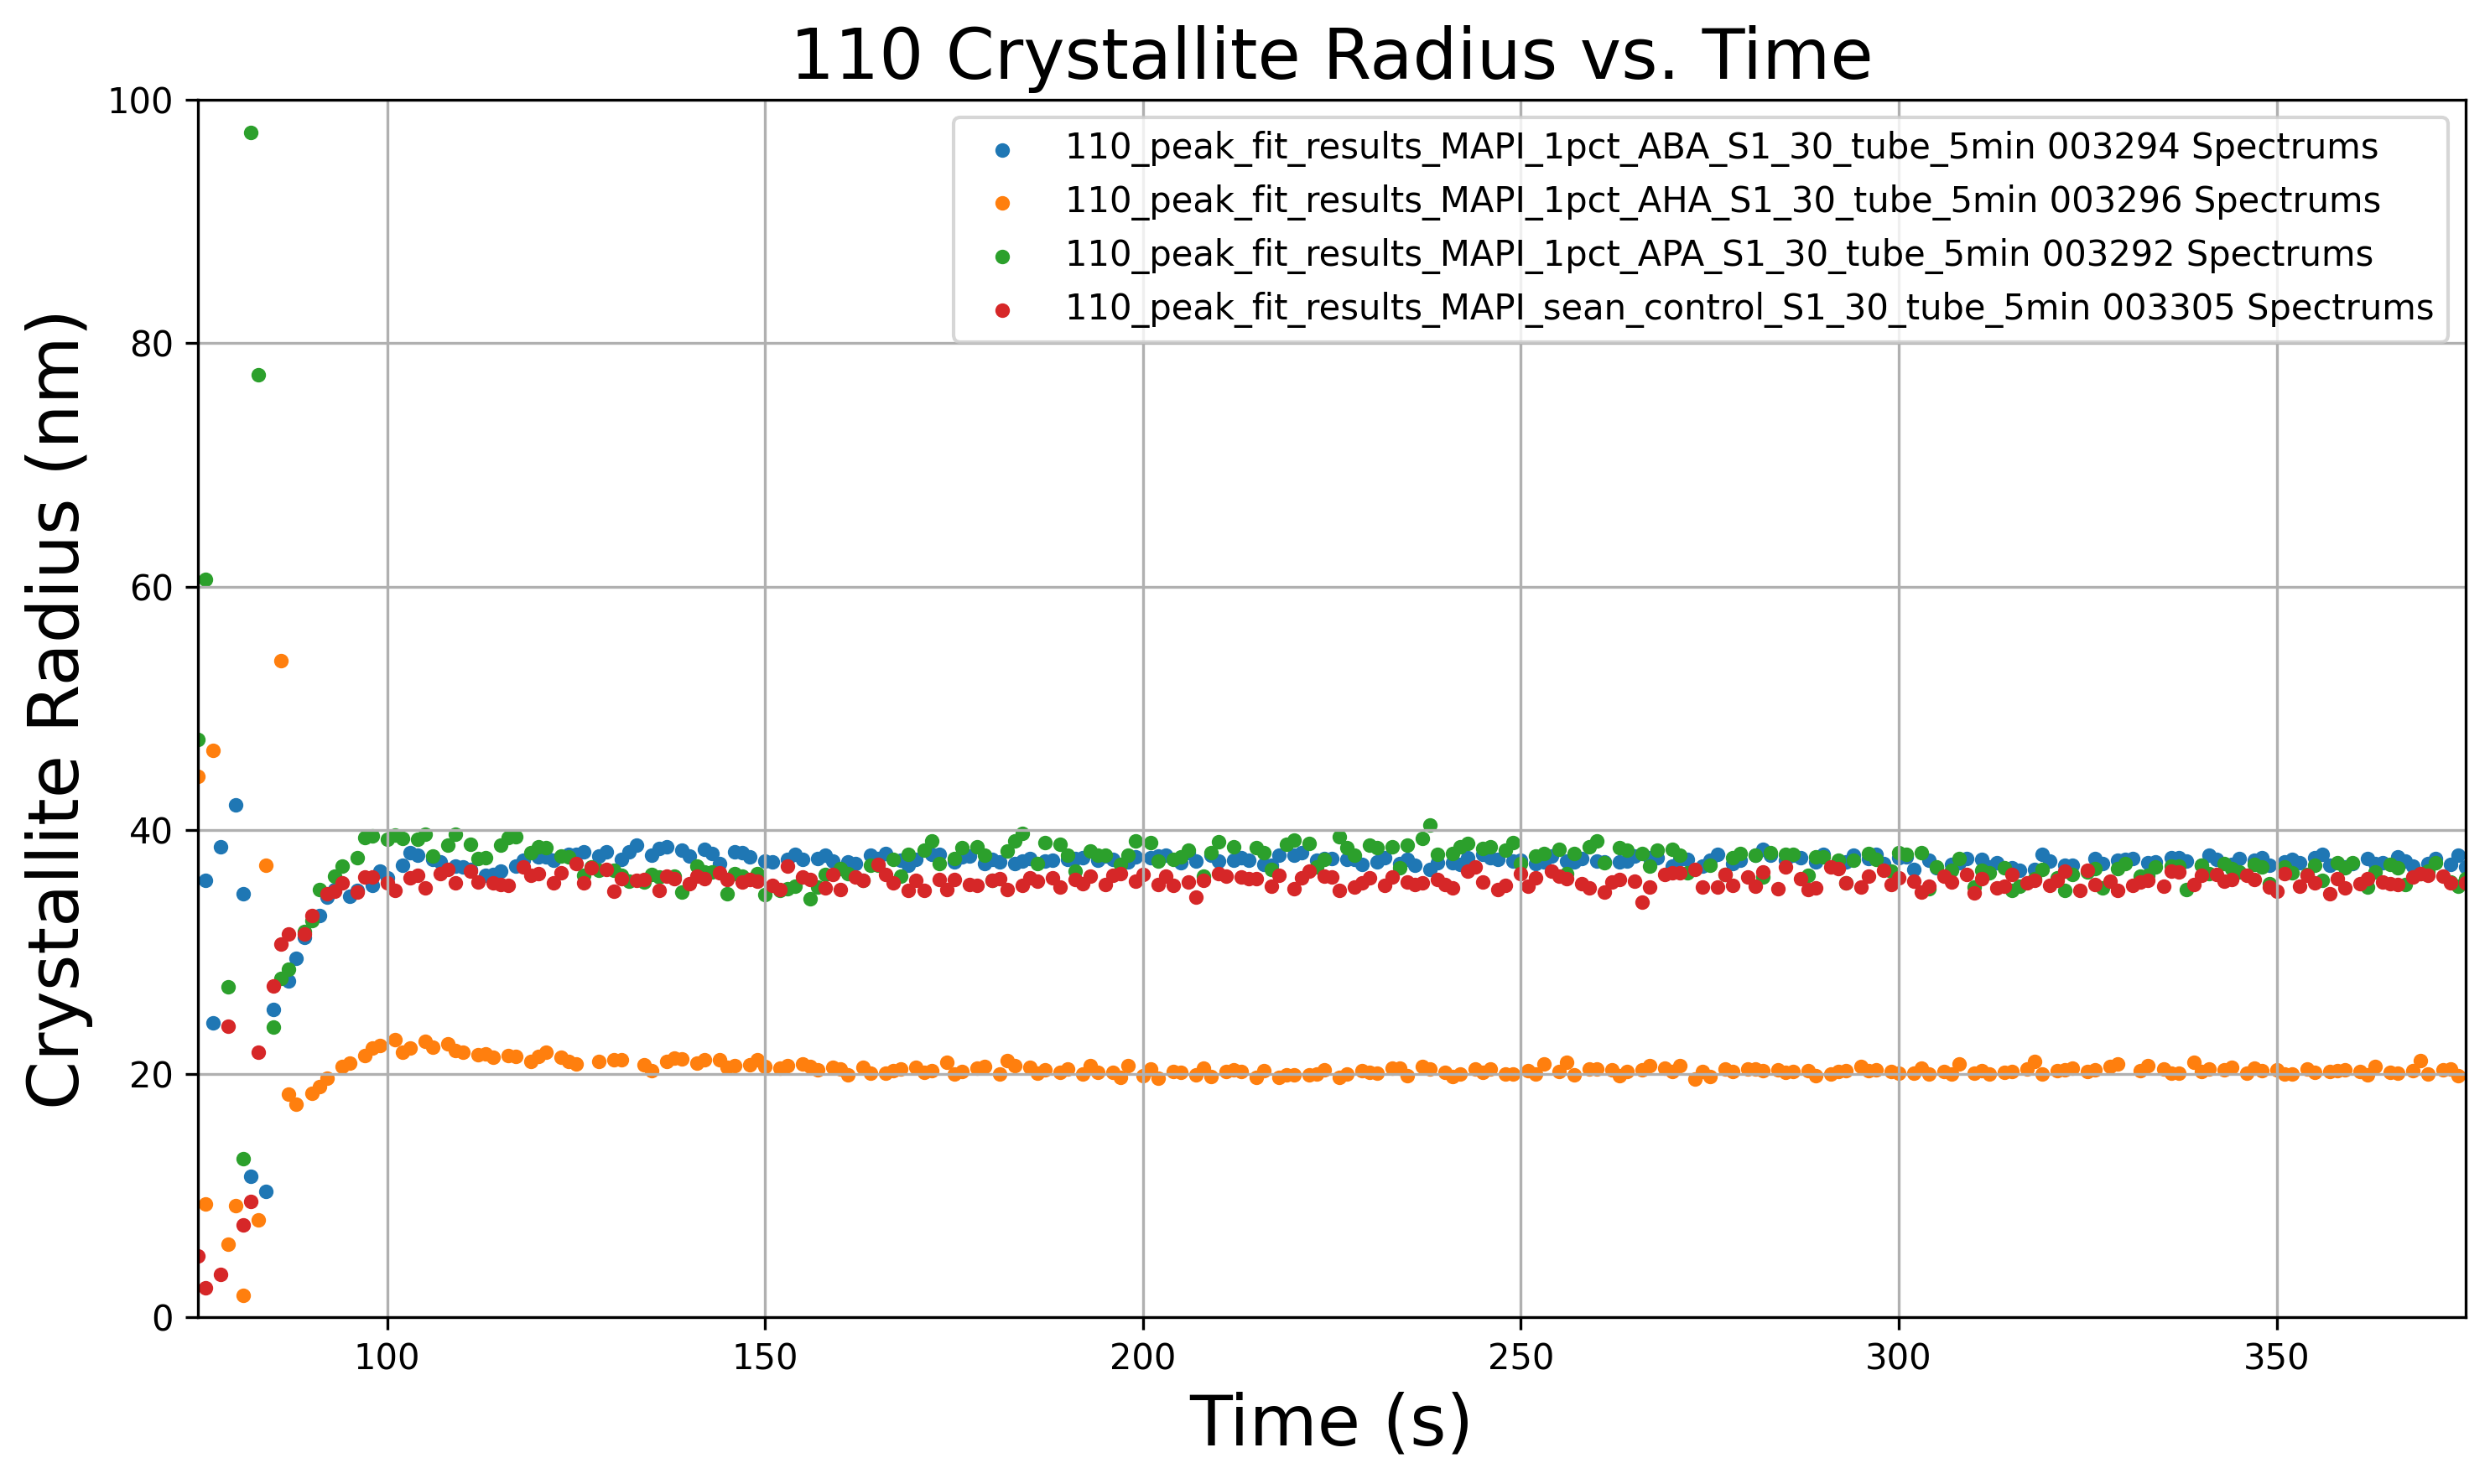

In [1]:
import pandas as pd
import numpy as np
import os
import glob
from matplotlib import pyplot as plt

start_time = 75  # seconds, starting point for the x-axis
peak = "110"
# Constants
k_shape = 0.9
experiment_end_time = 375  # seconds
data_dir = "/Users/pjlohr/Documents/GitHub/Patrick_Lohr/size_estimation_stuff/xrd_data"

# Get all CSV files in the directory
csv_files = glob.glob(os.path.join(data_dir, "*.csv"))

# Set up plot
plt.figure(figsize=(10, 6), dpi=300)
fs = 20

for file in csv_files:
    # Extract sample name from filename
    sample_name = os.path.splitext(os.path.basename(file))[0]
    
    # Load CSV
    df = pd.read_csv(file)
    
    # Define columns
    time_column = df.columns[0]
    amplitude_column = df.columns[1]
    peak_position_column = df.columns[2]
    sigma_column = df.columns[3]
    
    # Drop NaNs
    df_clean = df.dropna(subset=peak_position_column)
    
    # Compute FWHM from sigma
    fwhm_column = 'FWHM (1/Å)'
    df_clean[fwhm_column] = 2 * np.sqrt(2 * np.log(2)) * df_clean[sigma_column]
    
    # Filter to target time
    df_filtered = df_clean[df_clean[time_column] <= experiment_end_time]
    
    # Compute Scherrer size as radius (nm)
    
    scherrer_size = 2 * np.pi * k_shape / df_filtered[fwhm_column] / 10  # Calculate scherrer and convert from Å to nm
    df_filtered['Crystallite Radius (nm)'] = scherrer_size / (4 * np.pi / 3)**(1/3) # Scherrer size is taken to be the cube root of the volume of a sphere with the same radius as the crystallite size.
                                                                                    # This is a common approximation in crystallography for estimating the size of crystallites from X-ray diffraction data.

    # Plot
    plt.scatter(df_filtered[time_column],
             df_filtered['Crystallite Radius (nm)'],
             marker='o',
             label=sample_name,
             s=10
             )

# Final plot adjustments
plt.xlabel('Time (s)', fontsize=fs)
plt.ylabel('Crystallite Radius (nm)', fontsize=fs)
plt.title(peak + ' Crystallite Radius vs. Time', fontsize=fs)
plt.grid(True)
plt.xlim(start_time, experiment_end_time)  # Adjust x-limits as needed
plt.ylim(0, 100)  # Adjust y-limits as needed
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()